In [6]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv

In [7]:
load_dotenv()

True

In [8]:
class SubState(TypedDict):

    input_text: str
    translated_text: str

In [10]:
subgraph_llm = ChatGoogleGenerativeAI(
    model="gemini-3.5-flash-lite",
    temperature=0.2,
)

In [11]:
def translate_text(state: SubState):

    prompt = f"""
Translate the following text to Hindi.
Keep it natural and clear. Do not add extra content.

Text:
{state["input_text"]}
""".strip()
    
    translated_text = subgraph_llm.invoke(prompt).content

    return {'translated_text': translated_text}

In [12]:
subgraph_builder = StateGraph(SubState)

subgraph_builder.add_node('translate_text', translate_text)

subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph = subgraph_builder.compile()

In [13]:
class ParentState(TypedDict):

    question: str
    answer_eng: str
    answer_hin: str
    

In [16]:
parent_llm = ChatGoogleGenerativeAI(
    model="gemini-3.5-flash-lite",
    temperature=0.2,
)

In [17]:
def generate_answer(state: ParentState):

    answer = parent_llm.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}

In [18]:
def translate_answer(state: ParentState):

    # call the subgraph
    result = subgraph.invoke({'input_text': state['answer_eng']})

    return {'answer_hin': result['translated_text']}

In [19]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", translate_answer)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)

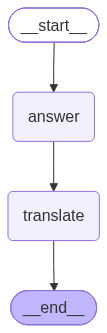

In [20]:
graph = parent_builder.compile()

graph

In [21]:
graph.invoke({'question': 'What is quantum physics'})

c:\Users\kumar\OneDrive\Desktop\Resume\Langraph\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.
c:\Users\kumar\OneDrive\Desktop\Resume\Langraph\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


{'question': 'What is quantum physics',
 'answer_eng': [{'type': 'text',
   'text': '**Quantum physics** (also known as quantum mechanics) is the branch of science that studies the universe at the smallest scales—at the level of atoms and subatomic particles (like electrons, protons, and photons). \n\nWhile classical physics (like Newton’s laws) explains how everyday objects like apples, cars, and planets move, quantum physics explains how the fundamental building blocks of nature work. At this microscopic level, the normal rules of reality break down, and things behave in very strange and counterintuitive ways.\n\nHere are the key concepts that define quantum physics:\n\n1. **Quantization (Packets of Energy):** \n   In the quantum world, certain properties—like energy, light, and momentum—don\'t flow in a continuous stream. Instead, they come in discrete, indivisible packets called **quanta**. \n\n2. **Wave-Particle Duality:** \n   Things we usually think of as particles (like electro